In [46]:
import pandas as pd
import glob
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Verify that the source files are structured identically
files = glob.glob("bquxjob_*.csv")
headers = [pd.read_csv(f, nrows=0).columns.tolist() for f in files]
all_same = all(h == headers[0] for h in headers)

all_same

True

In [48]:
# Read the source files and merge them into a single DataFrame
df_list = [pd.read_csv(f) for f in files]
df_merged = pd.concat(df_list, ignore_index=True)

df_merged.shape

(162965, 82)

In [49]:
# Sort the data by category, UPC, and week_ending
df_merged = df_merged.sort_values(["category", "upc", "week_ending"])
df_merged.head()

,category,niagara_personal_chars,niagara_personal_chars_alias,l1,l2,markets,generic_tag,retailers_name_tag,retailers_div_req,item,...,Holiday_Eastern_Easter,Holiday_Memorial_Day,Holiday_Veterans_Day,Holiday_Valentine_s_Day_n_Washington_s_Birthday,Holiday_New_Year_s_Day,Holiday_Labor_Day,Holiday_Eastern_Easter_n_Western_Easter,Holiday_Christmas_Day,Holiday_Columbus_Day,Holiday_clubbed
11954,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
14756,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
17554,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
84314,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
87119,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False


In [50]:
# Store the unique category values in a list
categories = df_merged["category"].unique().tolist()
categories

['HEALTH/NUTRITION SHAKES',
 'MEAL REPLACEMENT SHAKES',
 'PERFORMANCE NUTRITION SHAKES',
 'SPORT DRINKS',
 'VALUE ADD WATER',
 'WATER',
 nan]

In [51]:
# Select a Category to focus on and filter df_merged
ACTIVE_CATEGORY = categories[5]
ACTIVE_CATEGORY

'WATER'

In [52]:
# Filter df_merged for the selected category and store it in a separate data frame
df_active = df_merged[df_merged["category"] == ACTIVE_CATEGORY].copy()
df_active.shape

(41983, 82)

In [53]:
# Define a price promotion flag
df_active["price_promo"] = (
    df_active["price_decr_only_prc_acv"] > 0
)

In [54]:
# Define how many other SKUs in the category have a price promotion
df_active["competitor_promo_count"] = (
    df_active.groupby("week_ending")["price_promo"]
             .transform("sum")
    - df_active["price_promo"].astype(int)
)

In [55]:
### Exploratory Data Analysis

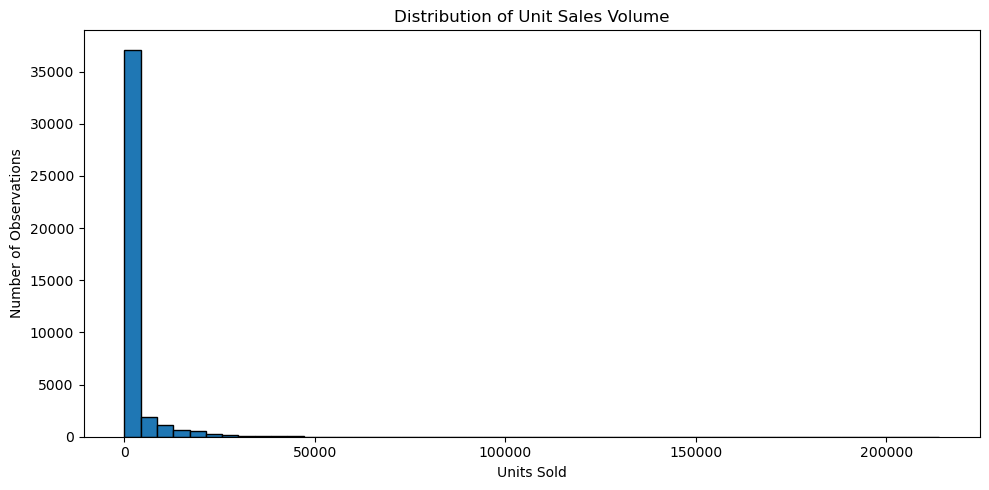

In [56]:
## Examine the distribution of units i.e response variable
plt.figure(figsize=(10, 5))

plt.hist(df_active["units"], bins=50, edgecolor="black")

plt.title("Distribution of Unit Sales Volume")
plt.xlabel("Units Sold")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

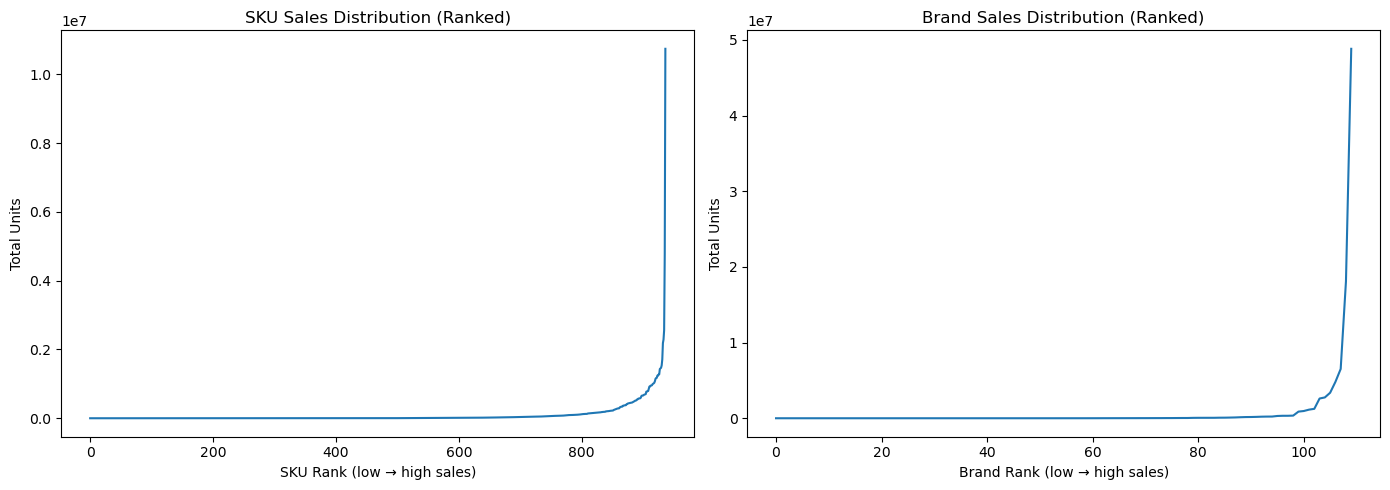

In [57]:
## Examine the distribution of SKU and brand performance in terms of total units sold

sku_units = df_active.groupby("upc")["units"].sum().sort_values()
brand_units = df_active.groupby("brand")["units"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# SKU sales distribution
axes[0].plot(sku_units.values)
axes[0].set_title("SKU Sales Distribution (Ranked)")
axes[0].set_xlabel("SKU Rank (low → high sales)")
axes[0].set_ylabel("Total Units")

# Brand sales distribution
axes[1].plot(brand_units.values)
axes[1].set_title("Brand Sales Distribution (Ranked)")
axes[1].set_xlabel("Brand Rank (low → high sales)")
axes[1].set_ylabel("Total Units")

plt.tight_layout()
plt.show()

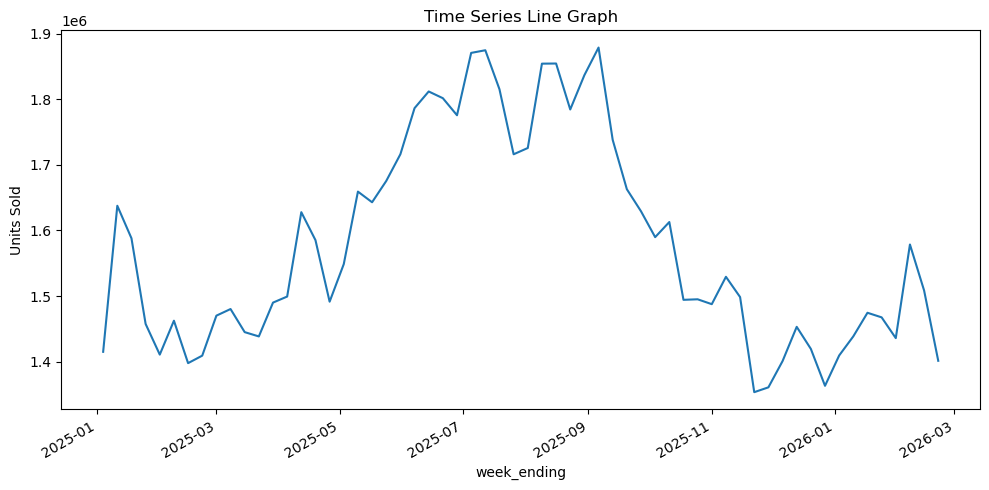

In [58]:
## Plot time-series data between week_ending and units
df_active["week_ending"] = pd.to_datetime(df_active["week_ending"])

weekly_units = df_active.groupby("week_ending")["units"].sum()

plt.figure(figsize=(10,5))
plt.plot(weekly_units.index, weekly_units.values)

plt.title("Time Series Line Graph")
plt.xlabel("week_ending")
plt.ylabel("Units Sold")

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

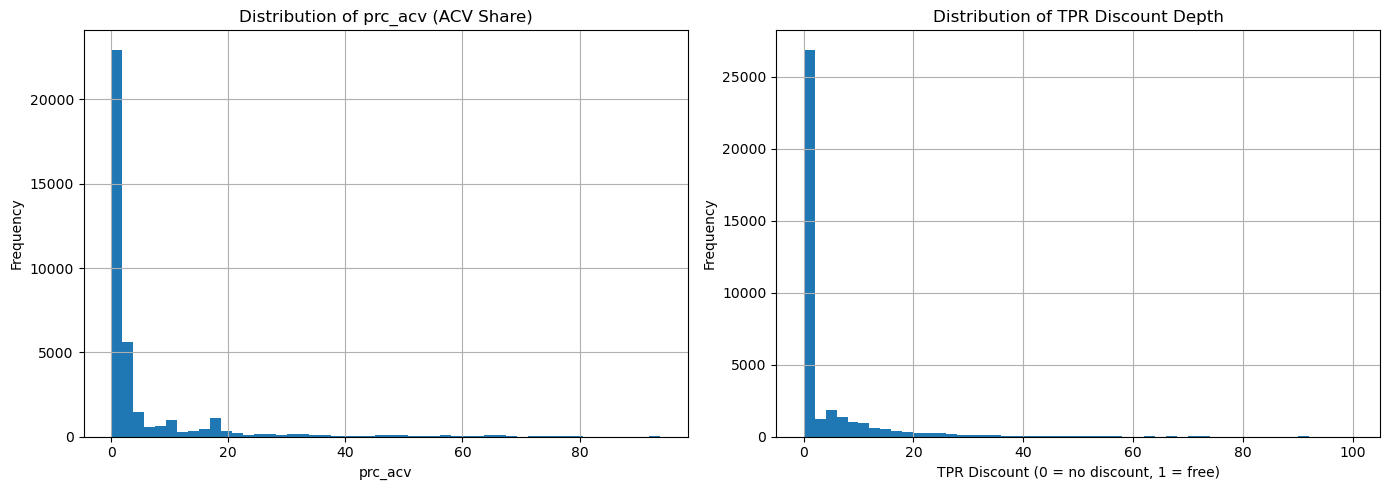

In [59]:
# Examine the frequency distributions of prc_acv and tpr_discount

fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_active["prc_acv"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution of prc_acv (ACV Share)")
axes[0].set_xlabel("prc_acv")
axes[0].set_ylabel("Frequency")

df_active["tpr_discount"].hist(bins=50, ax=axes[1])
axes[1].set_title("Distribution of TPR Discount Depth")
axes[1].set_xlabel("TPR Discount (0 = no discount, 1 = free)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

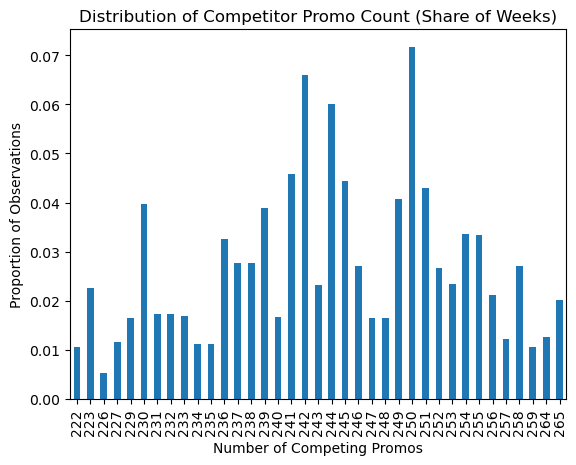

In [60]:
# Examine the competitive nature of price promotions within the category
(df_active["competitor_promo_count"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

plt.title("Distribution of Competitor Promo Count (Share of Weeks)")
plt.xlabel("Number of Competing Promos")
plt.ylabel("Proportion of Observations")
plt.show()

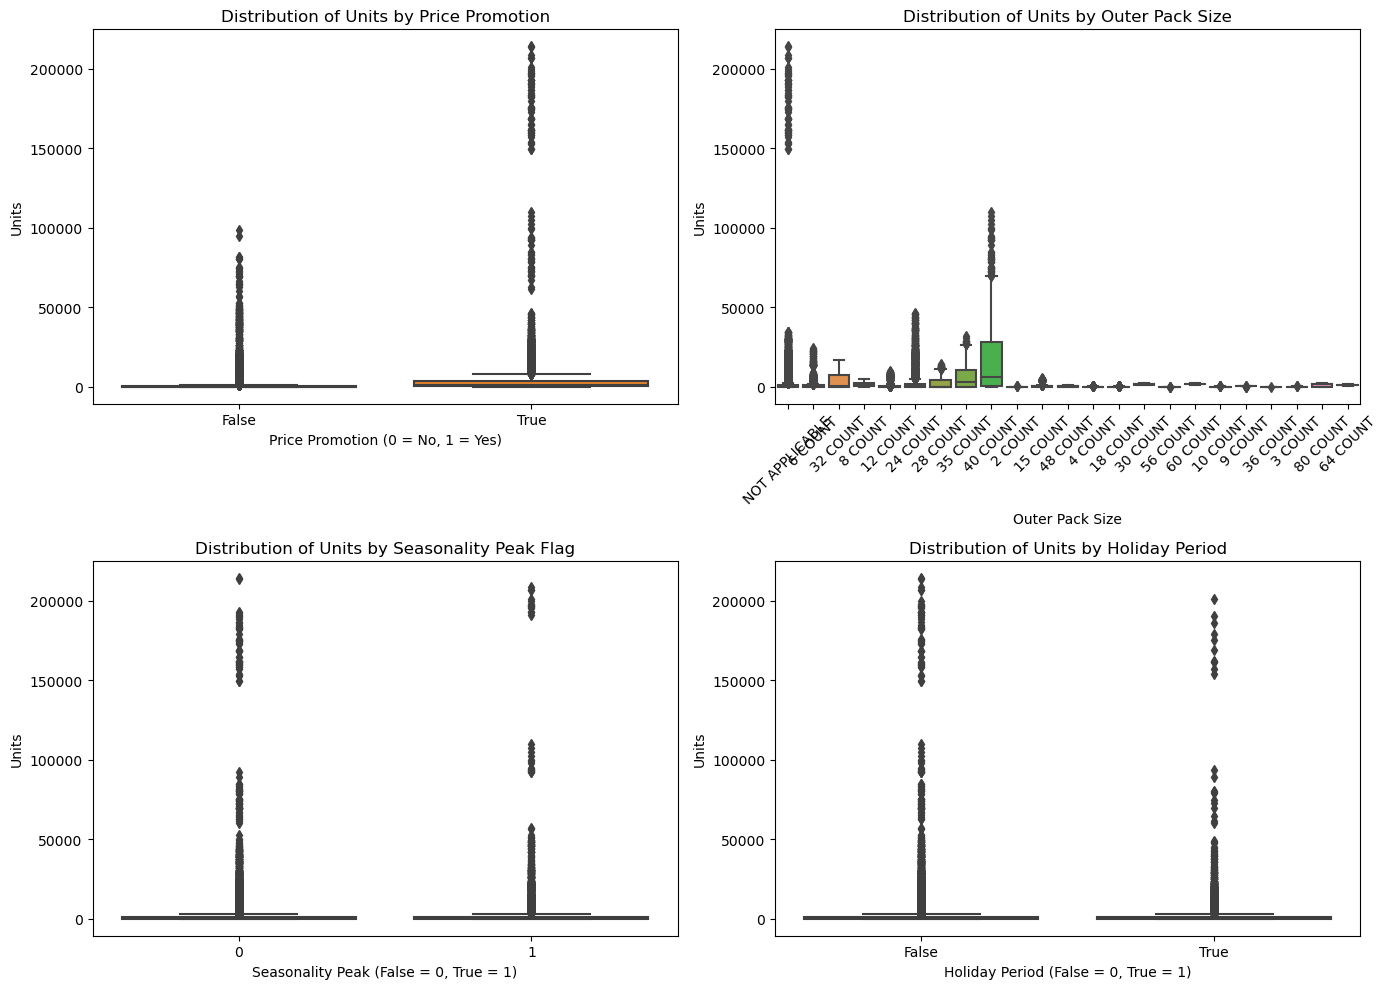

In [61]:
## Create boxplots for relevant categorical or binary predictors

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# price_promo
sns.boxplot(
    x="price_promo",
    y="units",
    data=df_active,
    ax=axes[0,0]
)

axes[0,0].set_title("Distribution of Units by Price Promotion")
axes[0,0].set_xlabel("Price Promotion (0 = No, 1 = Yes)")
axes[0,0].set_ylabel("Units")


# outer_pack_size
sns.boxplot(
    x="outer_pack_size",
    y="units",
    data=df_active,
    ax=axes[0,1]
)

axes[0,1].set_title("Distribution of Units by Outer Pack Size")
axes[0,1].set_xlabel("Outer Pack Size")
axes[0,1].set_ylabel("Units")
axes[0,1].tick_params(axis='x', rotation=45)


# seasonality_peak_flag
sns.boxplot(
    x="seasonality_peak_flag",
    y="units",
    data=df_active,
    ax=axes[1,0]
)

axes[1,0].set_title("Distribution of Units by Seasonality Peak Flag")
axes[1,0].set_xlabel("Seasonality Peak (False = 0, True = 1)")
axes[1,0].set_ylabel("Units")


# Holiday_clubbed
sns.boxplot(
    x="Holiday_clubbed",
    y="units",
    data=df_active,
    ax=axes[1,1]
)

axes[1,1].set_title("Distribution of Units by Holiday Period")
axes[1,1].set_xlabel("Holiday Period (False = 0, True = 1)")
axes[1,1].set_ylabel("Units")


plt.tight_layout()
plt.show()

In [62]:
### Multiple Log-Linear Regression - Simple Baseline Model

In [63]:
# Define the response variable using log(units) to measure proportional changes in demand
df_active["log_units"] = np.log1p(df_active["units"])

In [64]:
# Fit the regression
model = smf.ols(
    """
    log_units
    ~ C(upc)
    + C(week_ending)
    + prc_acv
    + price_promo
    + competitor_promo_count
    """,
    data=df_active
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     1015.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:09:06   Log-Likelihood:                -27846.
No. Observations:               37300   AIC:                         5.765e+04
Df Residuals:                   36319   BIC:                         6.602e+04
Df Model:                         980                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [65]:
### Model Diagnostics - Simple Baseline Multiple Log-Linear Regression Model

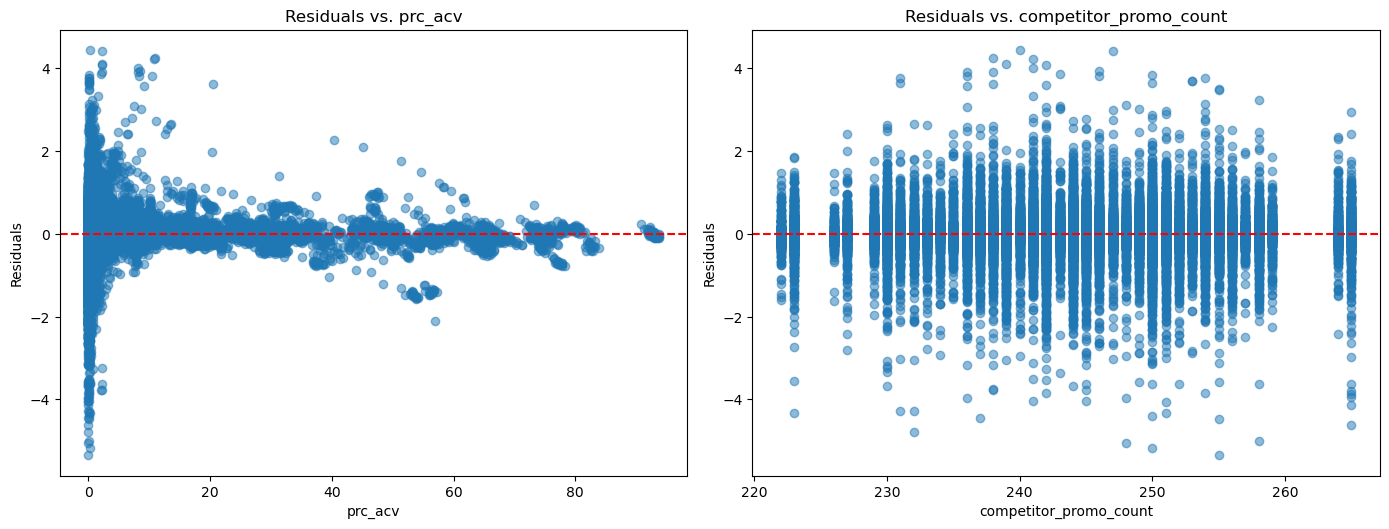

In [66]:
## Verify whether the linearity assumption holds for continuous, quantitative predictors in the model
# Derive the df that was used by statsmodels for model fitting
model_df = df_active.loc[model.model.data.row_labels]

# Calculate the residuals
residuals = model.resid

# Create scatter plots of the residuals vs. the quantitative predictors
plt.figure(figsize=(14, 10))

# Scatter plot for prc_acv
plt.subplot(2, 2, 1)
plt.scatter(model_df['prc_acv'], residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('prc_acv')
plt.ylabel('Residuals')
plt.title('Residuals vs. prc_acv')

# Scatter plot for competitor_promo_count
plt.subplot(2, 2, 2)
plt.scatter(model_df['competitor_promo_count'], residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('competitor_promo_count')
plt.ylabel('Residuals')
plt.title('Residuals vs. competitor_promo_count')

plt.tight_layout()
plt.show()

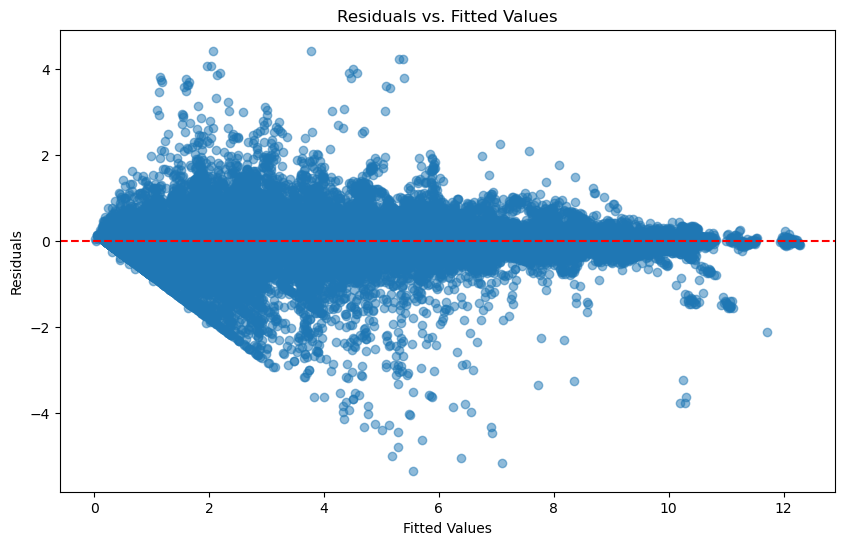

In [67]:
# Verify whether the constant variance and uncorrelated errors assumptions hold
# Calculate the fitted values
fitted_values = model.fittedvalues

# Create scatterplot of standardized residuals vs. fitted values
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

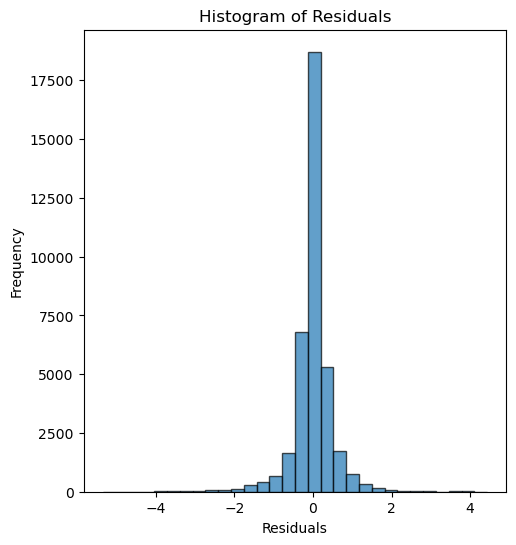

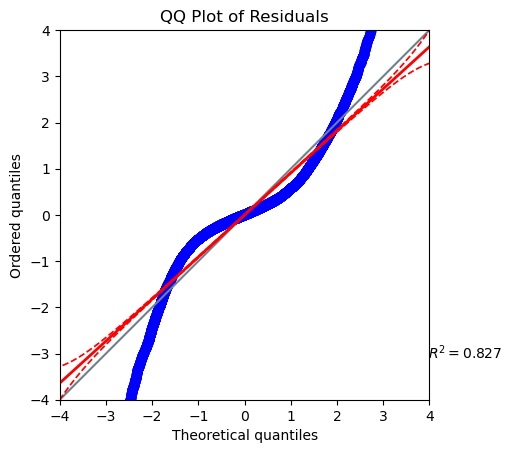

In [68]:
# Verify whether the normality assumption holds
# Create a histogram of the standardized residuals
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

# Display the plot
plt.show()

# Generate QQ plot
ax = pg.qqplot(residuals, dist='norm', confidence=.95)
ax.set_title('QQ Plot of Residuals')

# Set the axis limits
ax.set_xlim([-4, +4])
ax.set_ylim([-4, +4])

# Display the plot
plt.show()

In [69]:
### VIF Multicollinearity Check - Simple Baseline Multiple Log-Linear Regression Model
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

## Define the predictors to assess for multicollinearity
X = df_active[
    [
        "prc_acv",
        "price_promo",
        "competitor_promo_count"
    ]
].copy()

# Convert boolean variable to numeric (0/1)
X["price_promo"] = X["price_promo"].astype(int)

# Add intercept
X = add_constant(X)

# Remove any missing values
X = X.dropna()

## Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values.astype(float), i)
    for i in range(X.shape[1])
]

## Calculate the VIF threshold
r_squared = model.rsquared
vif_threshold = max(10, 1 / (1 - r_squared))

## Print the VIF values and the threshold
print(vif_data)
print(f"\nVIF Threshold: {vif_threshold:.2f}")

## Conclusion regarding multicollinearity
high_vif = vif_data[vif_data["VIF"] > vif_threshold]

print("\nVariables exceeding the threshold:")
print(high_vif)

                 Variable         VIF
0                   const  653.626011
1                 prc_acv    1.202997
2             price_promo    1.202759
3  competitor_promo_count    1.000651

VIF Threshold: 28.40

Variables exceeding the threshold:
  Variable         VIF
0    const  653.626011


C:\Users\abhi\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


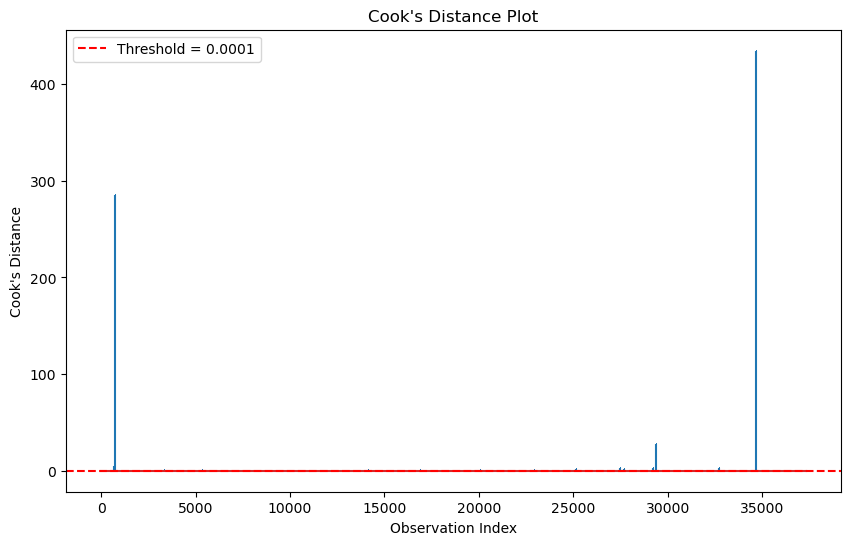

Cook's Distance Threshold: 0.0001
Number of outliers: 2087


In [70]:
### Outlier Check - Cook's Distance
## Calculate Cook's distances
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# Derive the dataframe used by statsmodels for model fitting
model_df = df_active.loc[model.model.data.row_labels]

## Plot Cook's distances
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")

threshold = 4 / len(model_df)

plt.axhline(
    y=threshold,
    color="r",
    linestyle="--",
    label=f"Threshold = {threshold:.4f}"
)

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.legend()
plt.show()

## Calculate the threshold
print(f"Cook's Distance Threshold: {threshold:.4f}")

## Identify influential observations
outliers = np.where(cooks_d > threshold)[0]
num_outliers = len(outliers)

print(f"Number of outliers: {num_outliers}")

In [71]:
### Multiple Log-Linear Regression - Interaction Terms Included

In [72]:
## Enhance the baseline model with relevant interaction terms to help address the Key Business Questions:
'''
1) Does promoting one SKU decrease sales for similar or adjacent SKUs?
2) What patterns or signals indicate cannibalization risk?
3) Are certain product types (pack sizes, sub-brands) more cross-sensitive?
4) How does promo timing or discount depth influence interactions?
5) What future models could measure cannibalization at scale?
'''

'\n1) Does promoting one SKU decrease sales for similar or adjacent SKUs?\n2) What patterns or signals indicate cannibalization risk?\n3) Are certain product types (pack sizes, sub-brands) more cross-sensitive?\n4) How does promo timing or discount depth influence interactions?\n5) What future models could measure cannibalization at scale?\n'

In [73]:
# Add interactions between competitor_promo_count and outer_pack_size, brand, seasonality_peak_flag, Holiday_clubbed, tpr_discount
model_interaction = smf.ols(
    """
    log_units
    ~ C(upc)
    + C(week_ending)
    + prc_acv
    + price_promo
    + competitor_promo_count
    + competitor_promo_count:C(outer_pack_size)
    + competitor_promo_count:C(brand)
    + competitor_promo_count:seasonality_peak_flag
    + competitor_promo_count:Holiday_clubbed
    + competitor_promo_count:tpr_discount
    """,
    data=df_active
).fit()

model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_units   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     905.2
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:09:38   Log-Likelihood:                -27691.
No. Observations:               37300   AIC:                         5.759e+04
Df Residuals:                   36194   BIC:                         6.702e+04
Df Model:                        1105                                         
Covariance Type:            nonrobust                                         
==============================================================================================================================================================================
                                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                     -0.0517      1.120     -0.046      0.963      -2.248       2.144
C(upc)[T.1200000108]                                                                                           7.4971      6.447      1.163      0.245      -5.139      20.133
C(upc)[T.1200000157]                                                                                           6.9075      6.447      1.072      0.284      -5.728      19.543
C(upc)[T.1200000159]                                                                                           4.3094      6.447      0.668      0.504      -8.327      16.946
C(upc)[T.1200000209]                                                                                           7.9452      6.446      1.232      0.218      -4.690      20.581
C(upc)[T.1200000317]                                                                                           1.4224      6.471      0.220      0.826     -11.262      14.106
C(upc)[T.1200000589]                                                                                           2.4733      6.447      0.384      0.701     -10.163      15.109
C(upc)[T.1200001311]                                                                                           9.7433      6.459      1.509      0.131      -2.916      22.403
C(upc)[T.1200001420]                                                                                           7.9882      6.481      1.233      0.218      -4.714      20.691
C(upc)[T.1200010044]                                                                                           1.4682      6.463      0.227      0.820     -11.200      14.136
C(upc)[T.1200010156]                                                                                           5.8649      6.453      0.909      0.363      -6.783      18.513
C(upc)[T.1200014097]                                                                                           6.9717      6.447      1.081      0.280      -5.664      19.607
C(upc)[T.1200019458]                                                                                           5.7959      6.447      0.899      0.369      -6.840      18.432
C(upc)[T.1200050404]                                                                                           7.9364      6.449      1.231      0.218      -4.704      20.576
C(upc)[T.1801610022]                                                                                        

In [74]:
### Overall Category Model

In [75]:
## Define the response variable for weekly category-level units
# Aggregate to weekly category-level units
df_category = (
    df_active
    .groupby("week_ending", as_index=False)
    .agg(
        category_units=("units", "sum"),
        promo_sku_count=("price_promo", "sum"),
        avg_acv=("prc_acv", "mean"),
        avg_discount=("tpr_discount", "mean")
    )
)

In [76]:
# Define a predictor to exclude a given SKU's units from the category_units
df_active["other_sku_units"] = (
    df_active.groupby("week_ending")["units"].transform("sum")
    - df_active["units"]
)

In [77]:
# Fit the direct cannibalization model
cannibalization_model = smf.ols(
    """
    np.log1p(other_sku_units)
    ~ price_promo
    + C(upc)
    + C(week_ending)
    """,
    data=df_active
).fit()

print(cannibalization_model.summary())

                                OLS Regression Results                               
Dep. Variable:     np.log1p(other_sku_units)   R-squared:                       1.000
Model:                                   OLS   Adj. R-squared:                  1.000
Method:                        Least Squares   F-statistic:                 1.262e+06
Date:                       Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                               20:10:01   Log-Likelihood:             2.5459e+05
No. Observations:                      41983   AIC:                        -5.072e+05
Df Residuals:                          40986   BIC:                        -4.986e+05
Df Model:                                996                                         
Covariance Type:                   nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [78]:
# Category Incrementality
category_incrementality_model = smf.ols(
    """
    np.log1p(category_units)
    ~ promo_sku_count
    + avg_discount
    + avg_acv
    """,
    data=df_category
).fit()

print(category_incrementality_model.summary())

                               OLS Regression Results                               
Dep. Variable:     np.log1p(category_units)   R-squared:                       0.264
Model:                                  OLS   Adj. R-squared:                  0.224
Method:                       Least Squares   F-statistic:                     6.687
Date:                      Wed, 10 Jun 2026   Prob (F-statistic):           0.000615
Time:                              20:10:02   Log-Likelihood:                 63.336
No. Observations:                        60   AIC:                            -118.7
Df Residuals:                            56   BIC:                            -110.3
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [79]:
## Verify whether the own SKU, cannibalization, and category incrementality models are consistent with observed outcomes

In [80]:
# Obtain model predictions
df_active["pred_units"] = np.expm1(model_interaction.fittedvalues)
df_active["pred_other_units"] = np.expm1(
    cannibalization_model.fittedvalues
)

In [81]:
# Aggregate to category-week level
decomp_check = df_active.groupby("week_ending", as_index=False).agg(
    actual_category_units=("units", "sum"),
    predicted_own_units=("pred_units", "sum"),
    predicted_other_units=("pred_other_units", "sum")
)

In [82]:
# Reconstruct category demand
decomp_check["reconstructed_category_units"] = (
    decomp_check["predicted_own_units"] +
    decomp_check["predicted_other_units"]
)

In [83]:
# Scale the reconstructed category demand to actual scale
scale_factor = (
    decomp_check["actual_category_units"].mean()
    / decomp_check["reconstructed_category_units"].mean()
)

decomp_check["reconstructed_category_units"] *= scale_factor

In [84]:
# Compute consistency metrics
decomp_check["absolute_error"] = (
    decomp_check["actual_category_units"] -
    decomp_check["reconstructed_category_units"]
).abs()

decomp_check["percentage_error"] = (
    decomp_check["absolute_error"] /
    decomp_check["actual_category_units"]
)

       absolute_error  percentage_error
count       60.000000         60.000000
mean     32446.696270          0.020564
std      19321.492510          0.011479
min       2287.533159          0.001418
25%      19083.182282          0.012463
50%      30490.499456          0.019296
75%      40852.527784          0.028430
max      87752.649271          0.048428

Correlation (Actual vs Reconstructed): 0.9921


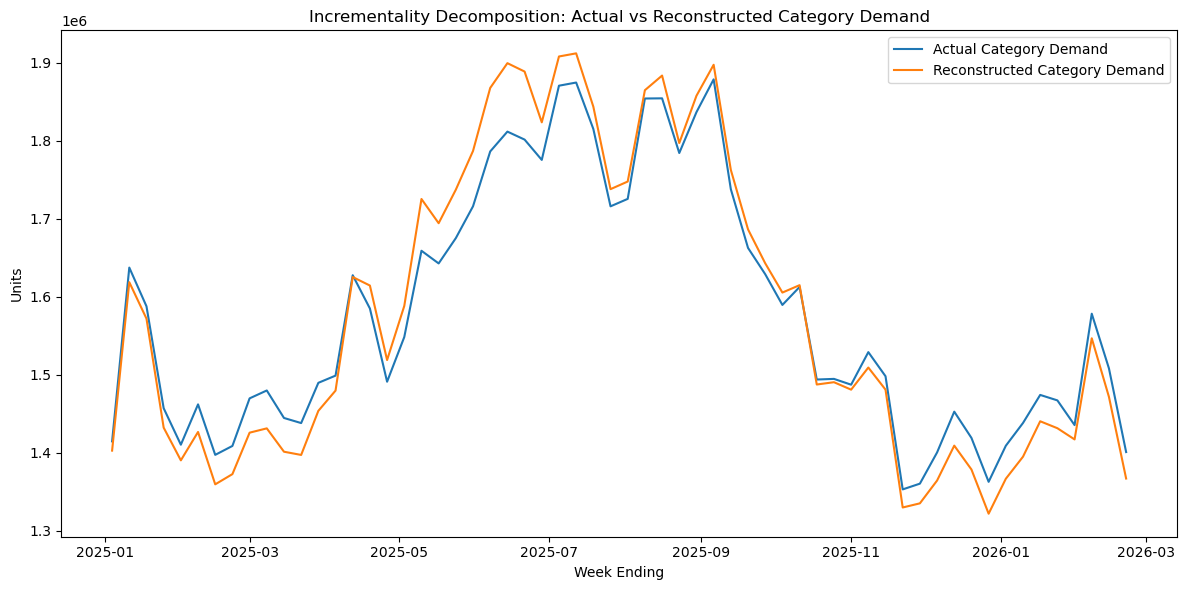

In [85]:
# Display the summary statistics, correlations, and plot of reconstructed_category_units vs. actual_category_units
print(
    decomp_check[["absolute_error", "percentage_error"]]
    .describe()
)


corr = decomp_check[
    ["actual_category_units", "reconstructed_category_units"]
].corr().iloc[0, 1]

print(f"\nCorrelation (Actual vs Reconstructed): {corr:.4f}")

plt.figure(figsize=(12, 6))

plt.plot(
    decomp_check["week_ending"],
    decomp_check["actual_category_units"],
    label="Actual Category Demand"
)

plt.plot(
    decomp_check["week_ending"],
    decomp_check["reconstructed_category_units"],
    label="Reconstructed Category Demand"
)

plt.title("Incrementality Decomposition: Actual vs Reconstructed Category Demand")
plt.xlabel("Week Ending")
plt.ylabel("Units")
plt.legend()

plt.tight_layout()
plt.show()